# Updating and comparing shared dataset releases

You'll pin the current shared dataset, fetch available Apple/Google reviews, create a new workable snapshot, and explicitly share it. Then you'll compare **record identities and changed values**, rather than assuming that every downloaded review is new.

## Getting started
Open this notebook in the publisher's container, started with `just up`. You need your initialized local raw store, AWS access, and the existing shared release. Run the cells in order. The update cell contacts live stores; the share cell uploads the new release and advances shared latest.

> **Note:** Apple RSS exposes a limited recent window. The collector cannot guarantee recovery of every missed review. Inspect completion/coverage information in its report. Google uses the configured overlap and request limits.


In [1]:
from pathlib import Path
import json
import os
import tomllib
import uuid

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

os.chdir("/workspace")  # ML modules and project config belong to this repository.
from voc import collector as co
from voc.paths import data_root
from voc.store import RawStore
from src.mlops.bootstrap import bootstrap
from src.mlops.pipeline import dataset_pipeline
from src.mlops.runner import code_identity, publish_run, share_run, validated_run

checkpoint_path = data_root() / "notebook-checkpoints/update-comparison.json"

def save_checkpoint():
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    temporary = checkpoint_path.with_suffix(".tmp")
    temporary.write_text(json.dumps(state, indent=2) + "\n")
    temporary.replace(checkpoint_path)

print("Checkpoint:", checkpoint_path)


Checkpoint: /data/notebook-checkpoints/update-comparison.json


## Pinning the previous shared release
Run the next cell to create or resume this comparison. Saving the release ID **before collecting** means the baseline won't change when shared latest advances.

Leave `START_NEW_COMPARISON = False` while working through this notebook, including after a restart. For a later update session, set it to `True`, run this cell once, then set it back to `False`. The previous checkpoint is archived automatically.


In [2]:
START_NEW_COMPARISON = False

if START_NEW_COMPARISON or not checkpoint_path.exists():
    if checkpoint_path.exists():
        checkpoint_path.rename(checkpoint_path.with_name(f"comparison-{uuid.uuid4()}.json"))
    baseline = co.get_dataset(source="s3")
    state = {
        "before_release_id": baseline.info["release_id"],
        "operation_id": str(uuid.uuid4()),
        "raw_revision_id": None,
        "run_id": None,
        "after_release_id": None,
    }
    save_checkpoint()
else:
    state = json.loads(checkpoint_path.read_text())

before = co.get_dataset(source="s3", version=state["before_release_id"])
print("Before release:", before.info["release_id"])
print("Before rows:", len(before.data))
print("Resuming pipeline run:", state["run_id"])


Before release: 41e10f26-0864-421e-8c5d-c7bbf309d113
Before rows: 78135
Resuming pipeline run: 1a1d51a6-1e25-4960-8e3f-2e9153f731ab


**Checkpoint:** for your first comparison, the baseline is release `41e10f26-0864-421e-8c5d-c7bbf309d113`, with 78,135 workable rows. A later comparison starts from the then-current shared release.

## Fetching available new observations
Run this cell to update your local raw store. Configuration is loaded immediately beforehand so `until = "run_start"` gets a fresh cutoff. The saved operation ID makes a successful retry reuse the same committed update.

The collector commits only when both providers satisfy their completion rules. `require_success()` checks the result; it does not perform the commit. A failure stops this notebook before preparation or sharing. If collection fails, inspect the report and fix the cause before retrying.


In [3]:
config = co.load_config("config/collector.toml")
result = co.update(
    store=config["raw_store"],
    config=config,
    operation_id=state["operation_id"],
)
print(json.dumps(result.report, indent=2))
result.require_success()
state["raw_revision_id"] = result.revision_id
save_checkpoint()
print("Committed raw revision:", result.revision_id)


{
  "completed_at": "2026-09-27T21:51:24.177961+00:00",
  "config": {
    "collector_dir": "/data/collector",
    "raw_store": "/data/raw/raw.db",
    "seed_path": "/seed/dataset.db",
    "sources": [
      {
        "app_id": "498483038",
        "country": "mx",
        "max_items": 500,
        "max_requests": 10,
        "provider": "apple_rss"
      },
      {
        "app_id": "com.citibanamex.banamexmobile",
        "country": "mx",
        "lang": "es",
        "max_items": 5000,
        "max_requests": 50,
        "provider": "play"
      }
    ],
    "update": {
      "max_capture_bytes": 104857600,
      "max_response_bytes": 2097152,
      "max_seconds": 300,
      "mode": "incremental",
      "overlap_days": 7,
      "until": "2026-09-27T21:50:15.731026+00:00",
      "until_basis": "run_start"
    }
  },
  "counts": {
    "duplicates": 1216,
    "edited": 61,
    "inserted": 1944,
    "stale": 0
  },
  "observations_sha256": "2fddbe17f3dd86818a93870a94dbbe6c02bebaf9dee8d90

**Checkpoint:** the report distinguishes inserted, edited and duplicate observations. Downloads and net dataset growth are different counts. Your shared baseline has not changed yet.

## Preparing and publishing the new snapshot locally
Run the pipeline with `refresh=False`: you already updated the collector. Keep the preparation rules unchanged if your aim is to measure changes in data alone.

The run ID is saved before personal publication, so you can retry a catalog write without rerunning a successful pipeline. A failed pipeline needs another successful run; the collector's committed raw revision remains available.


In [4]:
assert state["raw_revision_id"], "Complete the collector update first."
config = co.load_config("config/collector.toml")
with open("config/preparation.toml", "rb") as stream:
    rules = tomllib.load(stream)

if state["run_id"] is None:
    assert RawStore(config["raw_store"]).revision()["id"] == state["raw_revision_id"], (
        "The raw store advanced outside this comparison. Start a new comparison."
    )
    bootstrap()
    completed = dataset_pipeline(
        config=config,
        rules=rules,
        refresh=False,
        operation_id=state["operation_id"],
        project_identity=code_identity(),
    )
    if completed is None:
        raise RuntimeError("Pipeline did not return a completed run")
    state["run_id"] = str(completed.id)
    save_checkpoint()

candidate_info, _ = validated_run(state["run_id"])
assert candidate_info["raw_revision_id"] == state["raw_revision_id"], "Unexpected raw input"
published = publish_run(state["run_id"])
assert published["rules"] == before.info["rules"], (
    "Preparation rules changed. Interpret differences as data AND policy changes; "
    "review the policies before sharing."
)
print("Personal run:", published["run_id"])
print("Workable rows:", published["row_count"])


Initiating a new run for the pipeline: dataset_pipeline.
Caching is disabled by default for dataset_pipeline.
Using user: default
Using stack: voc-s3-9cfc0776-d12f-4175-98ec-bd90ca3eb2b6
  orchestrator: voc-local
  artifact_store: voc-artifacts-s3-9cfc0776-d12f-4175-98ec-bd90ca3eb2b6
  experiment_tracker: voc-mlflow
  log_store: default
You can visualize your pipeline runs in the ZenML Dashboard. In order to try it locally, please run zenml login --local.
Step raw_revision has started.
Found credentials in environment variables.
Step raw_revision has finished in 1.445s.
Step prepare has started.
Step prepare has finished in 9.630s.
Step track has started.
Failed to disable MLflow autologging for the following frameworks: ['fastai'].
Step track has finished in 1.374s.
Pipeline run has finished in 12.528s.
Personal run: 1a1d51a6-1e25-4960-8e3f-2e9153f731ab
Workable rows: 80079


## Sharing the matching pair
Run the next cell to upload the matching raw/workable release and advance shared latest. This is the explicit **team publication** step. It does not fetch reviews.

Repeating the share for the same run uses its persisted release attempt. An upload failure can be retried here; a newer competing shared release causes a conflict that needs review.


In [3]:
assert state["run_id"], "Prepare and publish the snapshot locally first."
if state["after_release_id"] is None:
    shared = share_run(state["run_id"])
    state["after_release_id"] = shared["release_id"]
    save_checkpoint()
    print(json.dumps(shared, indent=2))
else:
    print("Reusing shared release:", state["after_release_id"])

after = co.get_dataset(source="s3", version=state["after_release_id"])
assert after.info["raw_revision_id"] == state["raw_revision_id"]
print("Comparing releases:", before.info["release_id"], "→", after.info["release_id"])


Found credentials in environment variables.
Found credentials in environment variables.
{
  "status": "published",
  "format_version": 1,
  "release_id": "b7a61a8b-27d8-46a7-b2ce-67d97268b741",
  "manifest_key": "voc/datasets/releases/b7a61a8b-27d8-46a7-b2ce-67d97268b741.json",
  "manifest_sha256": "ca40ddfabf23fcd20d698ddfe8f26b1de60bff3a7fe22740a85c4414793992f5",
  "dataset_uri": "s3://itesm-mna-datos-equipo14-voc/voc/datasets",
  "raw_revision_id": "a83338e6-b608-4a1c-b270-9356d922e840",
  "artifact_id": "cc832e1a-bf72-4af6-821e-4291f65b016b",
  "raw_row_count": 80079,
  "workable_row_count": 80079
}
Comparing releases: 41e10f26-0864-421e-8c5d-c7bbf309d113 → b7a61a8b-27d8-46a7-b2ce-67d97268b741


## Comparing the two versions
Run the next cell to align rows by `record_id`. **Added** means an identity is only in the new workable dataset. **Changed** means the identity existed before but at least one of its 18 values changed. **Removed** means it no longer appears in the prepared output; this can result from preparation exclusions and is not evidence of raw-history deletion.

Null values compare as equal to other nulls. A rating edit counts even when the text hash stays unchanged. Both versions are pinned, so another team publication won't change this comparison.


In [4]:
assert list(before.data.columns) == list(after.data.columns), "Schemas must match"
old = before.data.set_index("record_id", verify_integrity=True)
new = after.data.set_index("record_id", verify_integrity=True)
added_ids = new.index.difference(old.index)
removed_ids = old.index.difference(new.index)
common_ids = old.index.intersection(new.index)
old_common, new_common = old.loc[common_ids], new.loc[common_ids]
equal = old_common.eq(new_common) | (old_common.isna() & new_common.isna())
changed_ids = common_ids[~equal.fillna(False).all(axis=1)]

added = new.loc[added_ids].reset_index()
removed = old.loc[removed_ids].reset_index()
changed = new.loc[changed_ids].reset_index()
unchanged_count = len(common_ids) - len(changed_ids)

counts = pd.Series({
    "Before": len(old), "After": len(new), "Added": len(added),
    "Changed": len(changed), "Removed": len(removed), "Unchanged": unchanged_count,
    "Net growth": len(new) - len(old),
}, name="rows")
assert counts["Net growth"] == counts["Added"] - counts["Removed"]
assert len(new) == len(added) + len(changed) + unchanged_count
display(counts.to_frame())


,rows
Before,78135
After,80079
Added,1944
Changed,61
Removed,0
Unchanged,78074
Net growth,1944


**Checkpoint:** net growth equals added minus removed; changed rows do not increase the row count. These are differences between workable releases, so collector observation counts can differ.

## Plotting the differences
Run the next cell to compare total rows by platform and the kinds of changes. The second plot keeps additions and edits visible even when the original dataset is much larger.


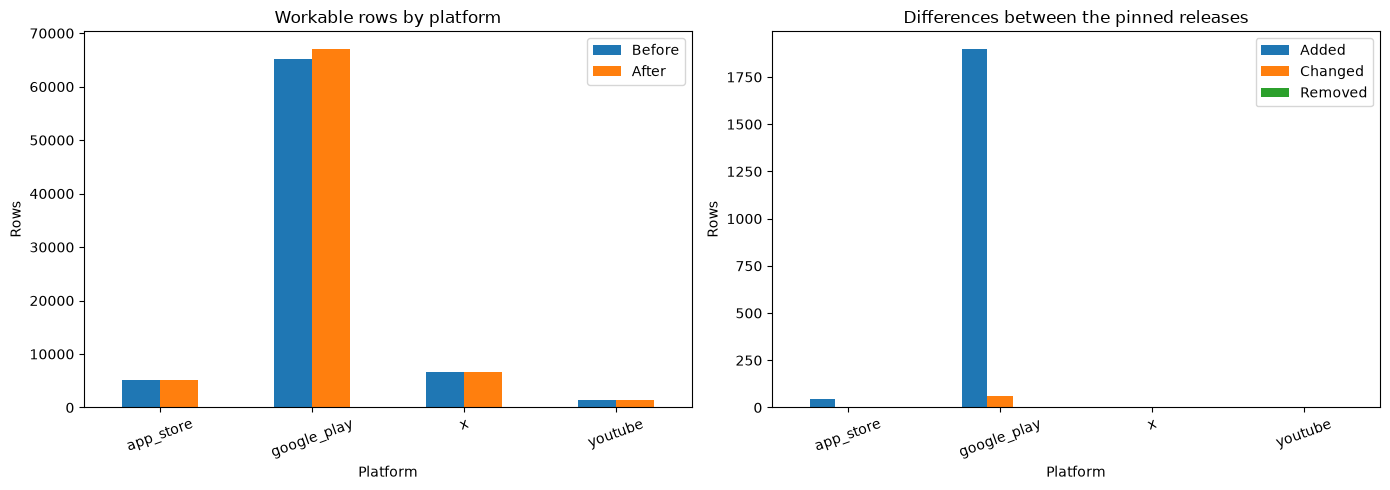

,Added,Changed,Removed
platform,,,
app_store,47,0,0
google_play,1897,61,0
x,0,0,0
youtube,0,0,0


In [5]:
platforms = sorted(set(old.platform.dropna()) | set(new.platform.dropna()))
totals = pd.DataFrame({
    "Before": old.platform.value_counts(),
    "After": new.platform.value_counts(),
}).reindex(platforms).fillna(0).astype(int)
changes = pd.DataFrame({
    "Added": added.platform.value_counts(),
    "Changed": changed.platform.value_counts(),
    "Removed": removed.platform.value_counts(),
}).reindex(platforms).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
totals.plot.bar(ax=axes[0], title="Workable rows by platform")
changes.plot.bar(ax=axes[1], title="Differences between the pinned releases")
for ax in axes:
    ax.set_xlabel("Platform")
    ax.set_ylabel("Rows")
    ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
plt.show()
display(changes)


Run this final cell to see the review dates of newly added identities. These are **source record dates**, not download dates: catching up can add older reviews. Unknown dates are reported separately.


New rows with unknown dates: 0


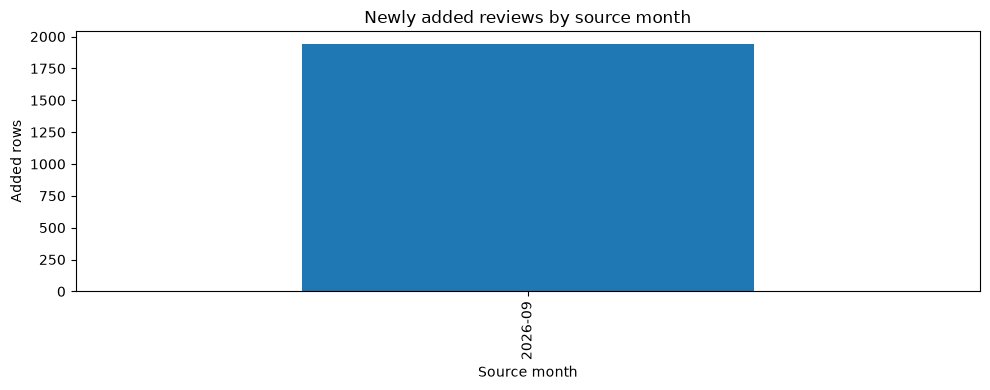

In [6]:
dates = pd.to_datetime(added["record_date"], utc=True, errors="coerce", format="mixed")
new_by_month = dates.dt.strftime("%Y-%m").value_counts().sort_index()
print("New rows with unknown dates:", int(dates.isna().sum()))
if new_by_month.empty:
    print("No newly added rows with known dates to plot.")
else:
    ax = new_by_month.plot.bar(figsize=(10, 4), title="Newly added reviews by source month")
    ax.set_ylabel("Added rows")
    ax.set_xlabel("Source month")
    plt.tight_layout()
    plt.show()


### Challenge: Inspect an edit
Pick an ID from `changed_ids` and compare `old.loc[id]` with `new.loc[id]`. Explain why it counts as changed without increasing the total number of reviews. If there were no edits, inspect an added identity instead.

## Key points

- **Raw updates** reconcile available observations by identity and retain revisions locally.
- **Preparation** creates a workable snapshot from a specific raw revision.
- **Personal publication** records a validated successful run in your local catalog.
- **Sharing** makes a matching raw/workable pair available through shared S3 latest.
- **Pinning** preserves the before/after comparison even after future releases.
- **Net growth** counts added minus removed identities; edits are counted separately.

Keep the checkpoint to resume this comparison. Save the notebook; clear outputs before committing if they contain review content you do not want in Git. Teammate onboarding remains the next infrastructure step.
